# Multiple Linear Regression Model - Advertisement

## Step 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Step 2. Create DataFrame

In [2]:
data = {
    'TV': [230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.8,
           66.1, 214.7, 23.8, 97.5, 204.1, 195.4, 67.8, 281.4, 69.2],
    'radio': [37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.1, 2.6,
              5.8, 24, 35.1, 7.6, 32.9, 47.7, 36.6, 39.6, 20.5],
    'newspaper': [69.2, 45.1, 69.3, 58.5, 58.4, 75, 23.5, 11.6, 1, 21.2,
                  24.2, 4, 65.9, 7.2, 46, 52.9, 114, 55.8, 18.3],
    'sales': [2210, 1040, 930, 1850, 1290, 720, 1180, 1320, 480, 1060,
              860, 1740, 920, 970, 1900, 2240, 1250, 2440, 1130]
}

df = pd.DataFrame(data)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,2210
1,44.5,39.3,45.1,1040
2,17.2,45.9,69.3,930
3,151.5,41.3,58.5,1850
4,180.8,10.8,58.4,1290


## Exploratory Data Analysis (Understand the Data)

### Take a Look to First 3 Rows

In [ ]:
df.head(3)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,2210
1,44.5,39.3,45.1,1040
2,17.2,45.9,69.3,930


### Take a Look to Last 3 Rows

In [ ]:
df.tail(3)

,TV,radio,newspaper,sales
16,67.8,36.6,114.0,1250
17,281.4,39.6,55.8,2440
18,69.2,20.5,18.3,1130


### Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         19 non-null     float64
 1   radio      19 non-null     float64
 2   newspaper  19 non-null     float64
 3   sales      19 non-null     int64  
dtypes: float64(3), int64(1)
memory usage: 740.0 bytes


### Shape

In [ ]:
df.shape

(19, 4)

### Descriptive Statistics

In [ ]:
df.describe()

,TV,radio,newspaper,sales
count,19.000000,19.000000,19.000000,19.000000
mean,117.836842,27.942105,43.215789,1343.684211
std,86.219830,15.838537,29.898853,557.536352
min,8.600000,2.100000,1.000000,480.000000
25%,51.000000,15.200000,19.750000,950.000000
50%,97.500000,32.900000,46.000000,1180.000000
75%,197.600000,39.450000,62.200000,1795.000000
max,281.400000,48.900000,114.000000,2440.000000


### Correlation Matrix

In [ ]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.011495,-0.030566,0.862811
radio,0.011495,1.000000,0.679680,0.433652
newspaper,-0.030566,0.679680,1.000000,0.217133
sales,0.862811,0.433652,0.217133,1.000000


### Heatmap

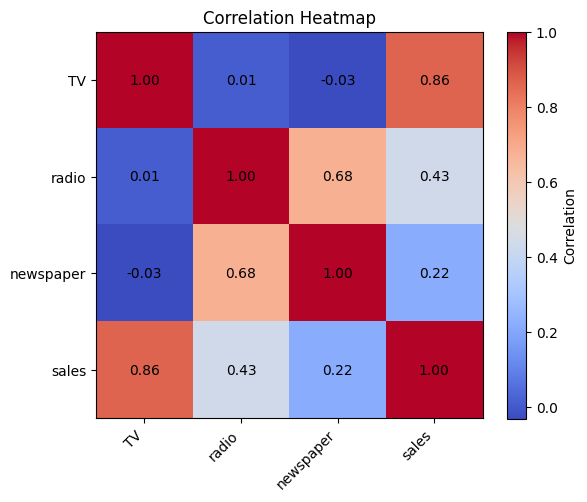

In [ ]:
corr = df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 3. Define Dependent and Independent Variables

In [3]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

## Step 4. Split the Data into Train and Test Sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Let's see the splitted data
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)


train_df.columns = ['TV', 'radio', 'newspaper', '   y_train']
test_df.columns = ['TV', 'radio', 'newspaper',  '    y_test']


print("-------Training Data--------")
print(train_df)
print("\n-------Testing Data-------")
print(test_df)

-------Training Data--------
       TV  radio  newspaper     y_train
8     8.6    2.1        1.0         480
16   67.8   36.6      114.0        1250
3   151.5   41.3       58.5        1850
13   97.5    7.6        7.2         970
15  195.4   47.7       52.9        2240
17  281.4   39.6       55.8        2440
2    17.2   45.9       69.3         930
9   199.8    2.6       21.2        1060
18   69.2   20.5       18.3        1130
4   180.8   10.8       58.4        1290
12   23.8   35.1       65.9         920
7   120.2   19.6       11.6        1320
10   66.1    5.8       24.2         860
14  204.1   32.9       46.0        1900
6    57.5   32.8       23.5        1180

-------Testing Data-------
       TV  radio  newspaper      y_test
0   230.1   37.8       69.2        2210
5     8.7   48.9       75.0         720
11  214.7   24.0        4.0        1740
1    44.5   39.3       45.1        1040


## Step 5. Build and Train the Model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Step 6. Make Predictions by Using Test Data

In [7]:
y_pred = model.predict(X_test)

## Step 7. Show Actual vs Predicted Values

In [8]:
results = pd.DataFrame({'Actual Y': y_test.values, 'Predicted Y': y_pred.round(0)})

print("\nTest Results:")
print(results.to_string(index=False, justify='center'))



Test Results:
 Actual Y  Predicted Y
   2210      2079.0   
    720      1178.0   
   1740      1881.0   
   1040      1236.0   



## Step 8. Make a prediction for user input

In [10]:
TV_input = float(input("Enter TV advertisement expenditure: "))
radio_input = float(input("Enter radio advertisement expenditure: "))
newspaper_input = float(input("Enter newspaper advertisement expenditure: "))

# Create a DataFrame for prediction
new_data = pd.DataFrame({'TV': [TV_input], 'radio': [radio_input], 'newspaper': [newspaper_input]})

# Predict Y
predicted_y = model.predict(new_data)[0]

print(f"\nPredicted sales for TV = {TV_input}, radio = {radio_input} and newspaper = {newspaper_input} expenditure is: {predicted_y:.1f}")

Enter TV advertisement expenditure: 4
Enter radio advertisement expenditure: 5
Enter newspaper advertisement expenditure: 6

Predicted sales for TV = 4.0, radio = 5.0 and newspaper = 6.0 expenditure is: 432.3
